# 22_vmf_switching_pvar_prototype
Run and inspect the regime-switching pooled VARX prototype (K=3 by default).


In [25]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import config
OUT = PROJECT_ROOT / config.OUTPUT_DIR


In [17]:
comparison = pd.read_csv(OUT / 'vmf_baseline_comparison.csv')
sw = pd.read_csv(OUT / 'switching_pvar_k3_metrics.csv')
display(pd.concat([comparison, sw], ignore_index=True, sort=False))


,mode,N_units,common_T,K,p,train_frac,train_end,baseline_task,task_levels,mse,...,accuracy,kl,cross_entropy,rf,rg,rh,max_iter,tol,n_regimes,ridge
0,vmf_pooled_factor_pvar,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.088761,...,0.439895,1.620278,1.757424,3.0,3.0,3.0,15.0,0.0001,NaN,NaN
1,baseline_persistence,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.143966,...,0.425296,10.085363,10.222510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline_pooled_varx_ridge,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.088804,...,0.439773,1.402474,1.539621,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,baseline_markov_transition,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.094931,...,0.425562,1.496940,1.634087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,baseline_multinomial_logit,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.088747,...,0.440565,1.395643,1.532790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,switching_pvar_k3,302,5870,7,65,0.7,4109,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,0.091637,...,0.432729,1.454445,1.591592,NaN,NaN,NaN,NaN,NaN,3.0,1.0


In [28]:
art = np.load(OUT / 'switching_pvar_k3_artifacts.npz', allow_pickle=True)
print(art.files)
print('Pi=')
print(art['Pi'])


['units', 'tasks', 'feature_names', 'x_mean', 'x_std', 'y_true_oof', 'y_pred_oof', 'regime_prob_pred', 'regime_prob_filt', 'W', 'sigma2', 'Pi', 'pi0', 'loss_history', 'train_end']
Pi=
[[0.61424414 0.17125461 0.21450125]
 [0.30298957 0.45483699 0.24217344]
 [0.27401011 0.17648875 0.54950114]]


In [31]:
import numpy as np
from pathlib import Path
import config

# OUT = Path(config.OUTPUT_DIR)

# art =  np.load(OUT / 'switching_pvar_k3_artifacts.npz', allow_pickle=True)

print(art.files)
print("\nTransition matrix Pi:")
print(art['Pi'])

print("\nInitial probabilities pi0:")
print(art['pi0'])

['units', 'tasks', 'feature_names', 'x_mean', 'x_std', 'y_true_oof', 'y_pred_oof', 'regime_prob_pred', 'regime_prob_filt', 'W', 'sigma2', 'Pi', 'pi0', 'loss_history', 'train_end']

Transition matrix Pi:
[[0.61424414 0.17125461 0.21450125]
 [0.30298957 0.45483699 0.24217344]
 [0.27401011 0.17648875 0.54950114]]

Initial probabilities pi0:
[0.3746193  0.19647232 0.42890838]


In [32]:
import pandas as pd

Pi = art['Pi']
Pi_df = pd.DataFrame(
    Pi,
    index=[f"from_regime_{i+1}" for i in range(Pi.shape[0])],
    columns=[f"to_regime_{j+1}" for j in range(Pi.shape[1])]
)
display(Pi_df)

,to_regime_1,to_regime_2,to_regime_3
from_regime_1,0.614244,0.171255,0.214501
from_regime_2,0.302990,0.454837,0.242173
from_regime_3,0.274010,0.176489,0.549501


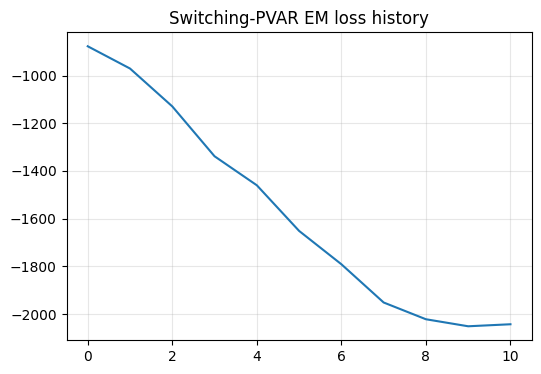

In [4]:
plt.figure(figsize=(6,4))
plt.plot(art['loss_history'])
plt.title('Switching-PVAR EM loss history')
plt.grid(alpha=0.3)
plt.show()


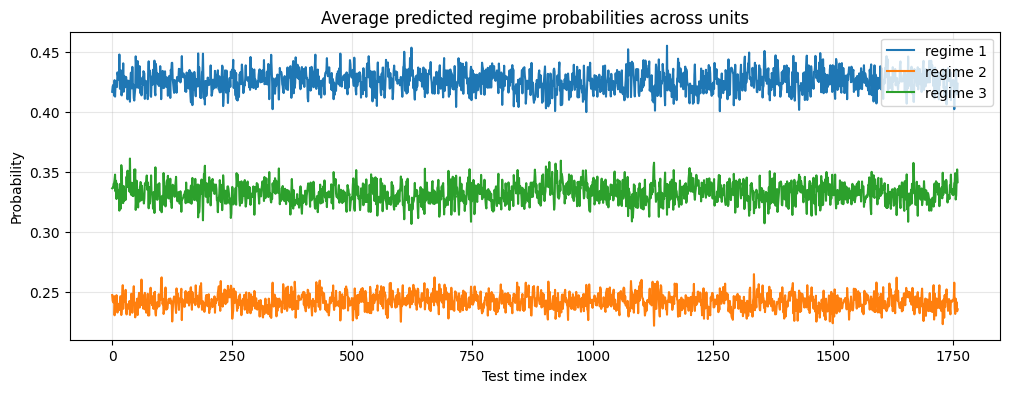

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import config

# OUT = Path(config.OUTPUT_DIR)
# art = np.load(OUT / 'switching_pvar_k3_artifacts.npz', allow_pickle=True)

regime_prob = art['regime_prob_pred']   # shape: stacked test rows x K
units = art['units']
train_end = int(art['train_end'][0])

# infer dimensions
n_units = len(units)
n_test_rows = regime_prob.shape[0]
K = regime_prob.shape[1]

test_T = n_test_rows // n_units
regime_prob_3d = regime_prob.reshape(n_units, test_T, K)

mean_prob = regime_prob_3d.mean(axis=0)

plt.figure(figsize=(12,4))
for k in range(K):
    plt.plot(mean_prob[:, k], label=f"regime {k+1}")
plt.title("Average predicted regime probabilities across units")
plt.xlabel("Test time index")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

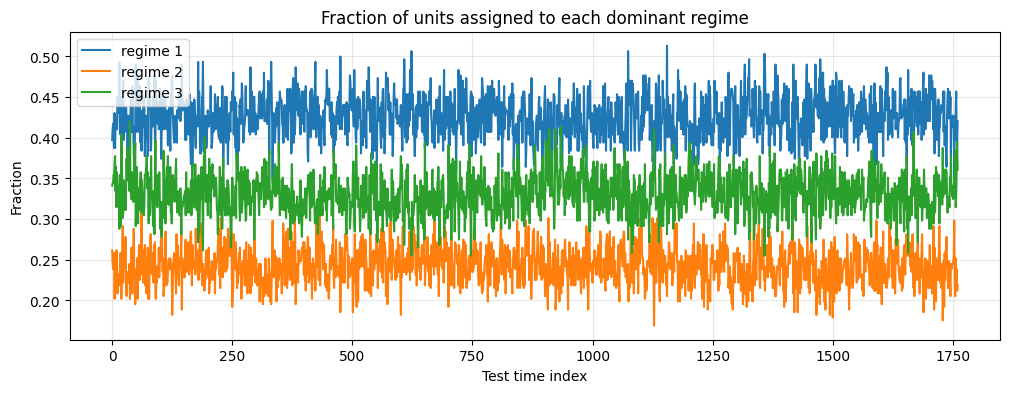

In [35]:
dom = np.argmax(regime_prob_3d, axis=2)   # n_units x test_T

freq = np.zeros((test_T, K))
for t in range(test_T):
    for k in range(K):
        freq[t, k] = np.mean(dom[:, t] == k)

plt.figure(figsize=(12,4))
for k in range(K):
    plt.plot(freq[:, k], label=f"regime {k+1}")
plt.title("Fraction of units assigned to each dominant regime")
plt.xlabel("Test time index")
plt.ylabel("Fraction")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

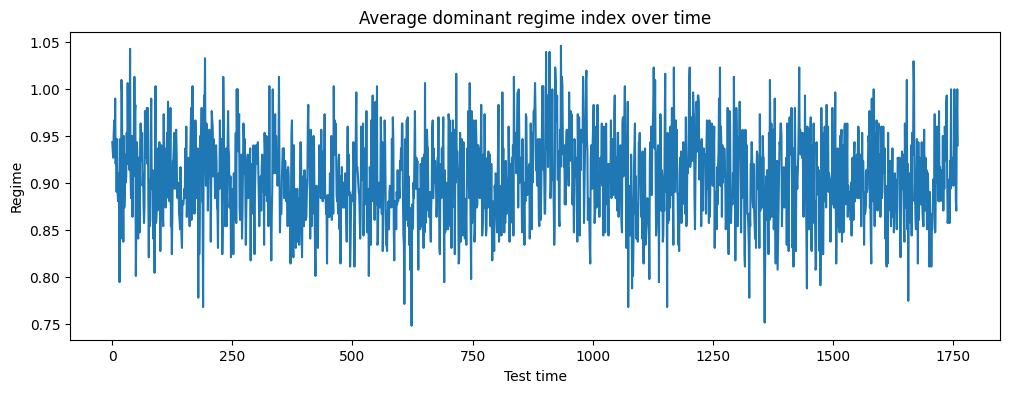

In [36]:
dom_regime = np.argmax(regime_prob_3d, axis=2)

plt.figure(figsize=(12,4))
plt.plot(dom_regime.mean(axis=0))
plt.title("Average dominant regime index over time")
plt.xlabel("Test time")
plt.ylabel("Regime")
plt.show()

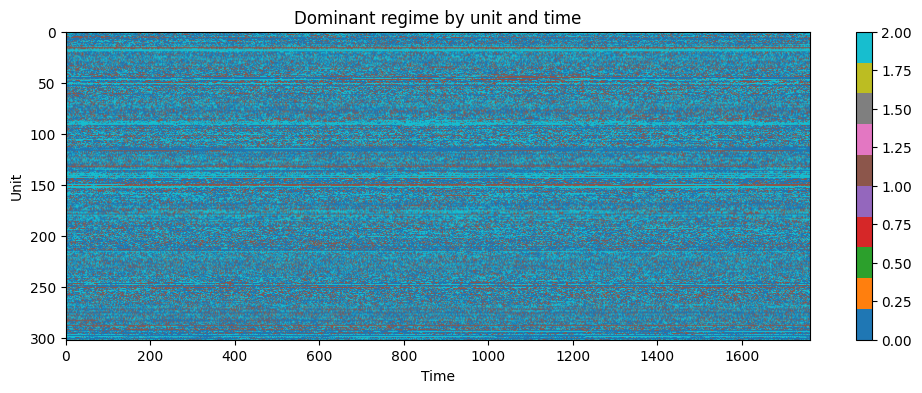

In [37]:
plt.figure(figsize=(12,4))
plt.imshow(dom_regime, aspect='auto', cmap='tab10')
plt.title("Dominant regime by unit and time")
plt.xlabel("Time")
plt.ylabel("Unit")
plt.colorbar()
plt.show()

In [38]:
import numpy as np

Pi = art['Pi']

w, v = np.linalg.eig(Pi.T)
stationary = np.real(v[:, np.isclose(w,1)])
stationary = stationary / stationary.sum()

print(stationary.flatten())

[0.42592053 0.24147301 0.33260646]


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# PROJECT_ROOT = Path.cwd().parent
# if str(PROJECT_ROOT) not in sys.path:
#     sys.path.insert(0, str(PROJECT_ROOT))
import config

OUT = Path(PROJECT_ROOT/config.OUTPUT_DIR)
art = np.load(OUT / 'switching_pvar_k3_artifacts.npz', allow_pickle=True)

print(art.files)

['units', 'tasks', 'feature_names', 'x_mean', 'x_std', 'y_true_oof', 'y_pred_oof', 'regime_prob_pred', 'regime_prob_filt', 'W', 'sigma2', 'Pi', 'pi0', 'loss_history', 'train_end']


In [47]:
W = art['W']
Pi = art['Pi']
sigma2 = art['sigma2']

print("W shape:", W.shape)
print("Pi shape:", Pi.shape)
print("sigma2 shape:", sigma2.shape)

W shape: (3, 73, 7)
Pi shape: (3, 3)
sigma2 shape: (3, 7)


In [48]:
feature_names = art['feature_names']
print("Number of covariates:", len(feature_names))
print(feature_names[:10])

Number of covariates: 65
['entropy' 'occupancy_roll_state_0' 'occupancy_roll_state_1'
 'occupancy_roll_state_2' 'occupancy_roll_state_3'
 'occupancy_roll_state_4' 'occupancy_roll_state_5'
 'occupancy_roll_state_6' 'switching_rate_roll' 'volatility_roll']


In [49]:
K = Pi.shape[0]
n_states = 7
p = len(feature_names)

In [50]:
print(W.shape)

(3, 73, 7)


In [51]:
if W.shape[1] == 1 + n_states + p:
    W_std = W
elif W.shape[2] == 1 + n_states + p:
    W_std = np.transpose(W, (0, 2, 1))
else:
    raise ValueError("Unexpected W shape")

print("Standardized W shape:", W_std.shape)

Standardized W shape: (3, 73, 7)


In [52]:
intercepts = W_std[:, 0, :]                  # K x 7
A_blocks   = W_std[:, 1:1+n_states, :]       # K x 7 x 7
B_blocks   = W_std[:, 1+n_states:, :]        # K x p x 7

print("intercepts:", intercepts.shape)
print("A_blocks:", A_blocks.shape)
print("B_blocks:", B_blocks.shape)

intercepts: (3, 7)
A_blocks: (3, 7, 7)
B_blocks: (3, 65, 7)


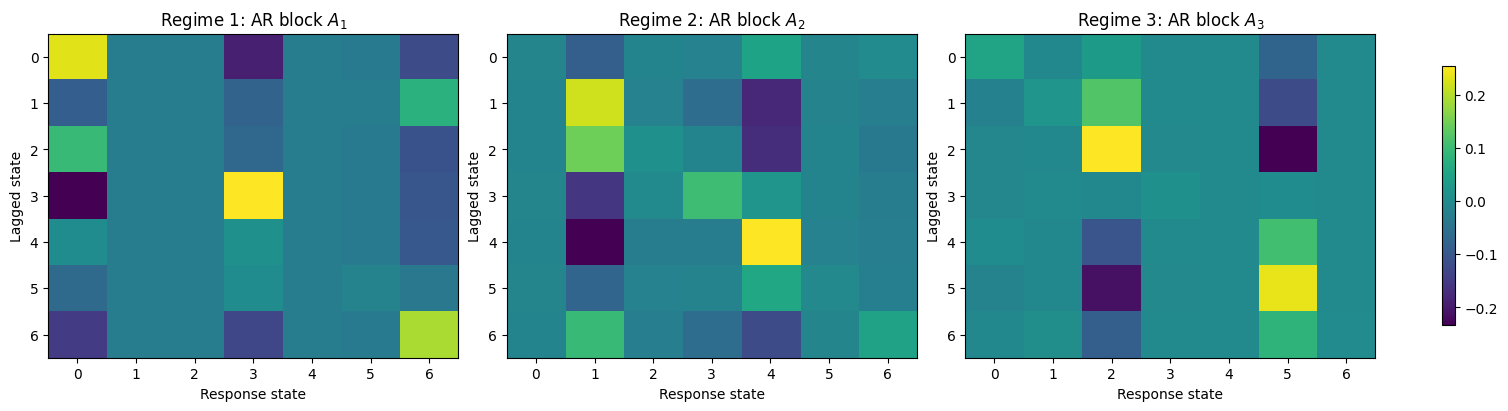

In [53]:
fig, axes = plt.subplots(1, K, figsize=(5*K, 4), constrained_layout=True)

for k in range(K):
    ax = axes[k] if K > 1 else axes
    im = ax.imshow(A_blocks[k], aspect='auto')
    ax.set_title(f"Regime {k+1}: AR block $A_{k+1}$")
    ax.set_xlabel("Response state")
    ax.set_ylabel("Lagged state")
    ax.set_xticks(range(n_states))
    ax.set_yticks(range(n_states))

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [54]:
diag_strength = []
offdiag_strength = []

for k in range(K):
    A = A_blocks[k]
    diag_strength.append(np.mean(np.diag(A)))
    offdiag_strength.append(np.mean(np.abs(A - np.diag(np.diag(A)))))

summary_A = pd.DataFrame({
    "regime": [f"regime_{k+1}" for k in range(K)],
    "mean_diag_A": diag_strength,
    "mean_abs_offdiag_A": offdiag_strength
})

display(summary_A)

,regime,mean_diag_A,mean_abs_offdiag_A
0,regime_1,0.088766,0.023712
1,regime_2,0.083726,0.027551
2,regime_3,0.082241,0.026428


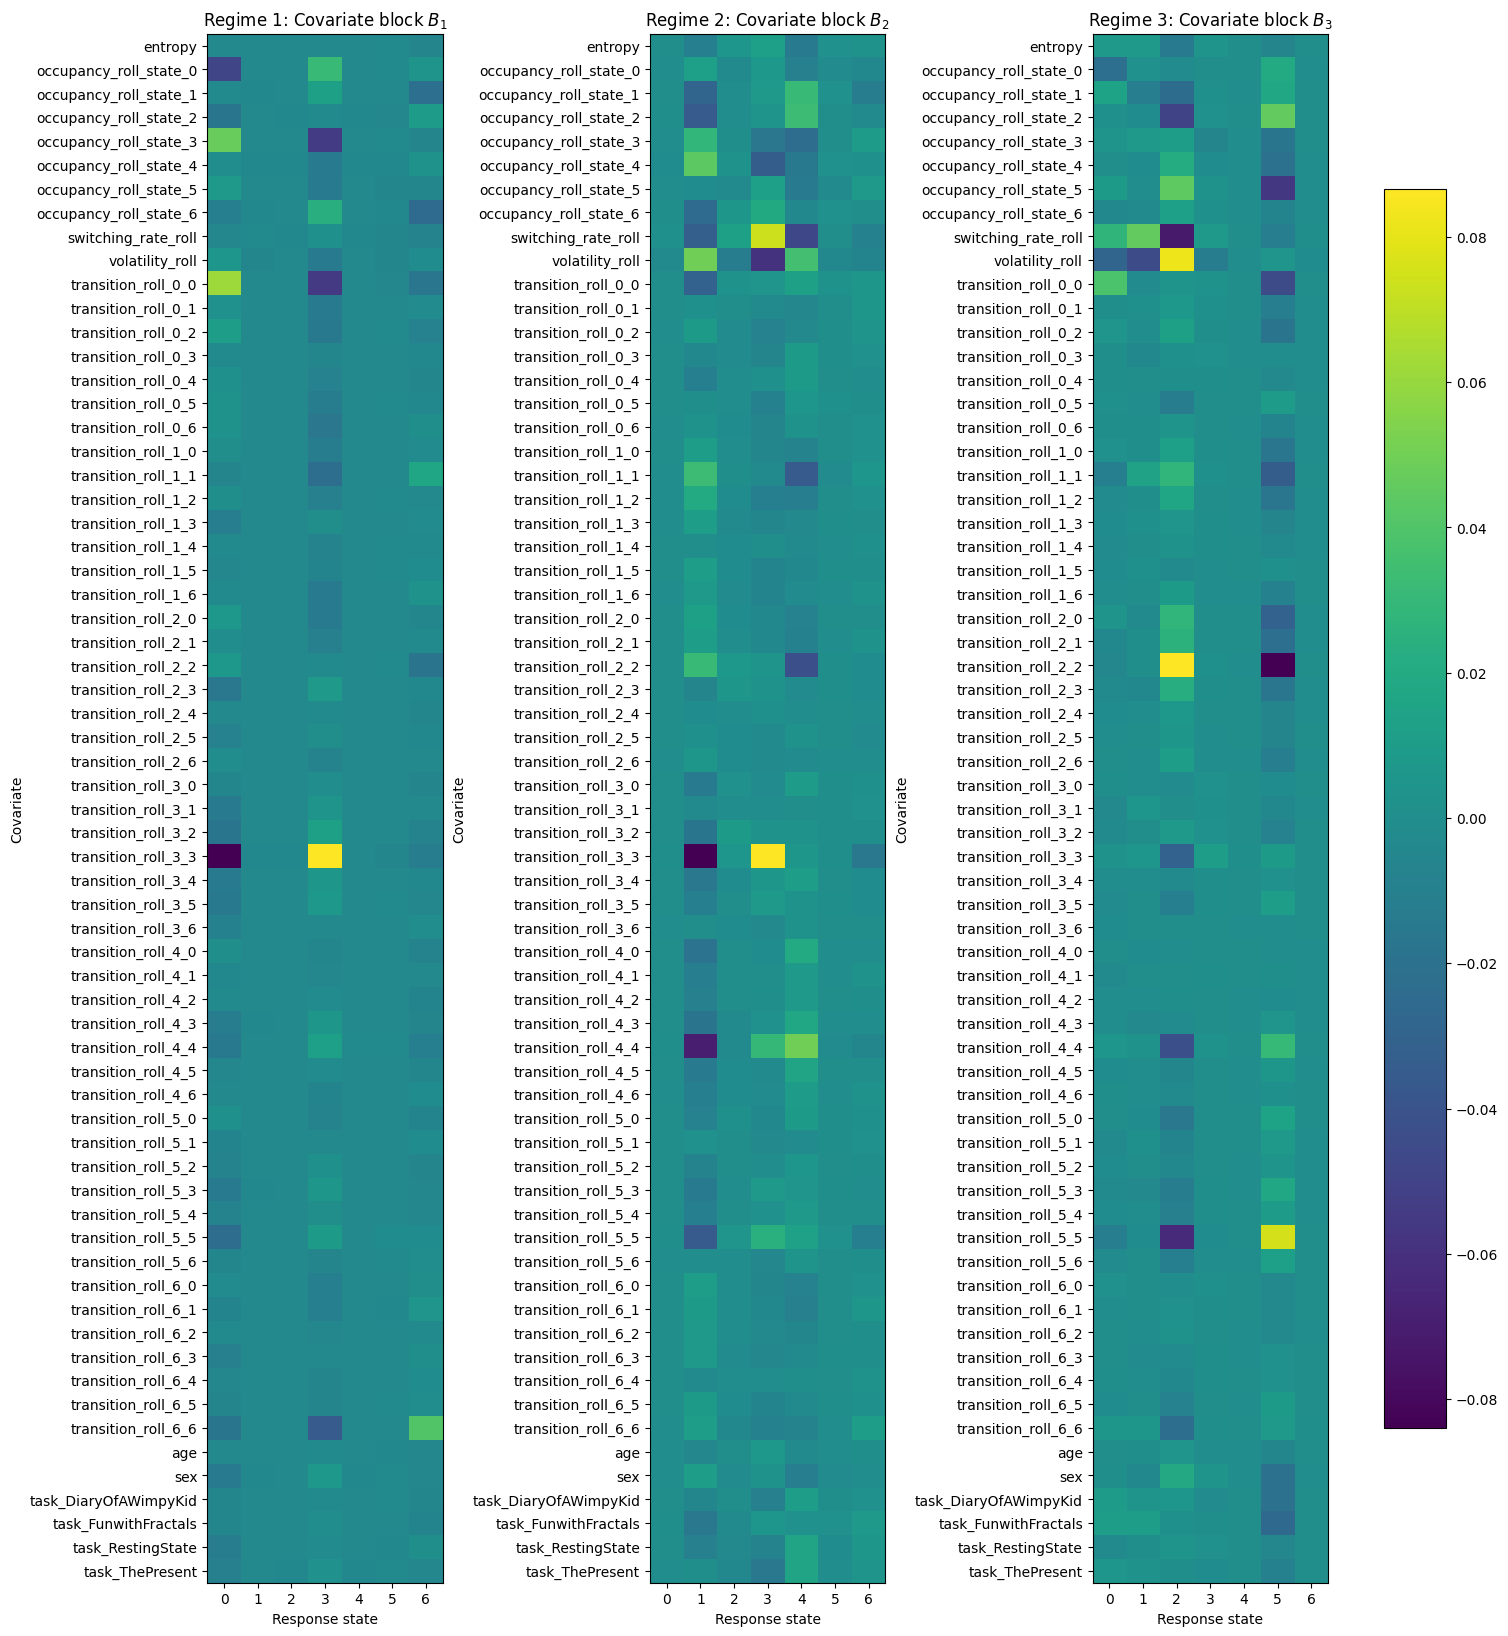

In [55]:
fig, axes = plt.subplots(1, K, figsize=(5*K, max(4, p*0.25)), constrained_layout=True)

for k in range(K):
    ax = axes[k] if K > 1 else axes
    im = ax.imshow(B_blocks[k], aspect='auto')
    ax.set_title(f"Regime {k+1}: Covariate block $B_{k+1}$")
    ax.set_xlabel("Response state")
    ax.set_ylabel("Covariate")
    ax.set_xticks(range(n_states))
    ax.set_yticks(range(p))
    ax.set_yticklabels(feature_names)

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

In [56]:
cov_importance = []

for k in range(K):
    imp = np.mean(np.abs(B_blocks[k]), axis=1)   # average across 7 response states
    cov_importance.append(imp)

cov_importance = np.array(cov_importance)  # K x p

for k in range(K):
    df = pd.DataFrame({
        "covariate": feature_names,
        "importance": cov_importance[k]
    }).sort_values("importance", ascending=False)
    
    print(f"\nTop covariates in regime {k+1}")
    display(df.head(10))


Top covariates in regime 1


,covariate,importance
34,transition_roll_3_3,0.039267
10,transition_roll_0_0,0.028359
4,occupancy_roll_state_3,0.022965
1,occupancy_roll_state_0,0.019304
58,transition_roll_6_6,0.019189
7,occupancy_roll_state_6,0.011823
18,transition_roll_1_1,0.009162
50,transition_roll_5_5,0.008179
2,occupancy_roll_state_1,0.007895
42,transition_roll_4_4,0.007712



Top covariates in regime 2


,covariate,importance
34,transition_roll_3_3,0.030461
8,switching_rate_roll,0.027007
9,volatility_roll,0.025885
42,transition_roll_4_4,0.024465
5,occupancy_roll_state_4,0.015124
50,transition_roll_5_5,0.013893
26,transition_roll_2_2,0.013269
2,occupancy_roll_state_1,0.012531
4,occupancy_roll_state_3,0.011990
18,transition_roll_1_1,0.011949



Top covariates in regime 3


,covariate,importance
26,transition_roll_2_2,0.025422
9,volatility_roll,0.024902
8,switching_rate_roll,0.023505
50,transition_roll_5_5,0.021689
6,occupancy_roll_state_5,0.016265
3,occupancy_roll_state_2,0.014146
10,transition_roll_0_0,0.013232
18,transition_roll_1_1,0.012708
42,transition_roll_4_4,0.012021
2,occupancy_roll_state_1,0.009995


In [57]:
rows = []
for k in range(K):
    A = A_blocks[k]
    B = B_blocks[k]
    rows.append({
        "regime": f"regime_{k+1}",
        "persistence_mean_diag": np.mean(np.diag(A)),
        "cross_state_mean_abs_offdiag": np.mean(np.abs(A - np.diag(np.diag(A)))),
        "covariate_mean_abs_effect": np.mean(np.abs(B)),
        "noise_mean": np.mean(sigma2[k])
    })

regime_summary = pd.DataFrame(rows)
display(regime_summary)

,regime,persistence_mean_diag,cross_state_mean_abs_offdiag,covariate_mean_abs_effect,noise_mean
0,regime_1,0.088766,0.023712,0.005303,0.059664
1,regime_2,0.083726,0.027551,0.006419,0.051765
2,regime_3,0.082241,0.026428,0.005492,0.046676
